In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import numpy as np
import math
import torch.nn as nn
import torch.optim as optim
from compressai.zoo import bmshj2018_hyperprior

In [ ]:
class LOLDataset(Dataset):
    def __init__(self, root_dir, crop_size=256):
        self.low_dir = os.path.join(root_dir, 'low')
        self.high_dir = os.path.join(root_dir, 'high')

        self.image_names = sorted(os.listdir(self.low_dir))
        self.crop_size = crop_size

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        # 1. 이미지 불러오기
        img_name = self.image_names[idx]
        low_img = Image.open(os.path.join(self.low_dir, img_name)).convert('RGB')
        high_img = Image.open(os.path.join(self.high_dir, img_name)).convert('RGB')

        # 2. 256x256 크기로 무작위로 자를 위치(좌표) 계산
        w, h = TF.get_image_size(low_img)
        crop_i = random.randint(0, h - self.crop_size) # 세로 자를 위치
        crop_j = random.randint(0, w - self.crop_size) # 가로 자를 위치

        # 3. 계산된 똑같은 위치로 low와 high 이미지를 동시에 자르기
        low_img = TF.crop(low_img, crop_i, crop_j, self.crop_size, self.crop_size)
        high_img = TF.crop(high_img, crop_i, crop_j, self.crop_size, self.crop_size)

        # 4. 50% 확률로 좌우 반전(Data Augmentation) 똑같이 적용
        if random.random() > 0.5:
            low_img = TF.hflip(low_img)
            high_img = TF.hflip(high_img)

        # 5. 파이토치가 읽을 수 있는 텐서(0~1 사이 숫자)로 변환
        low_tensor = TF.to_tensor(low_img)
        high_tensor = TF.to_tensor(high_img)

        return low_tensor, high_tensor

print("✅ LOL Dataset 클래스 에러 수정 완료!")

✅ LOL Dataset 클래스 에러 수정 완료!


📦 뽑혀 나온 Low 텐서 크기: torch.Size([4, 3, 256, 256])
📦 뽑혀 나온 High 텐서 크기: torch.Size([4, 3, 256, 256])


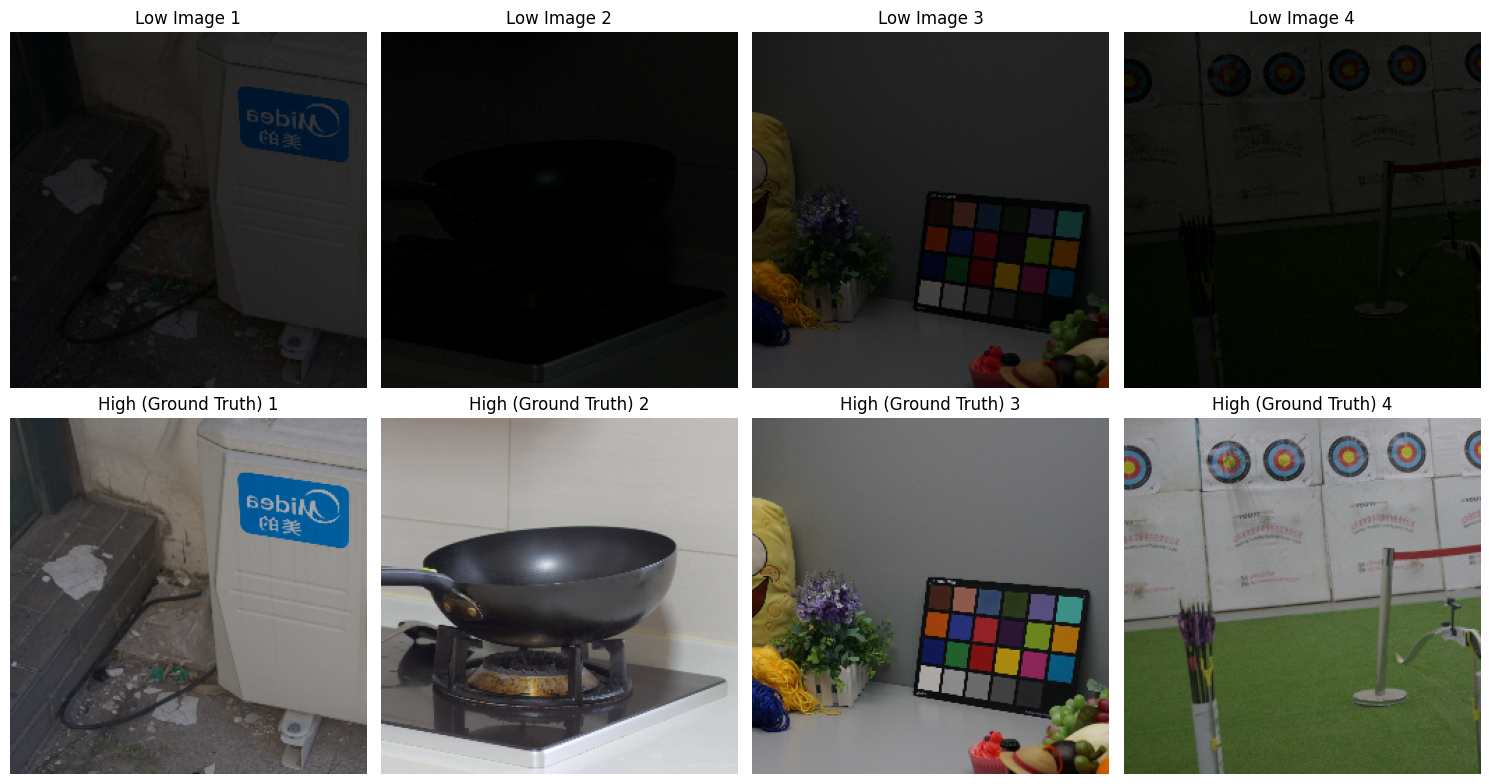

In [4]:
dataset_path = '/content/drive/MyDrive/CUAI_summer_conference/LOL_Dataset/lol_dataset/our485'

# 데이터셋 객체 생성
train_dataset = LOLDataset(root_dir=dataset_path, crop_size=256)

# 배치 사이즈(한 번에 모델에 넣을 묶음 개수)를 4로 설정
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# 딱 한 묶음(배치)만 뽑아보기
low_batch, high_batch = next(iter(train_loader))

print(f"📦 뽑혀 나온 Low 텐서 크기: {low_batch.shape}")
print(f"📦 뽑혀 나온 High 텐서 크기: {high_batch.shape}")

# 시각화해서 확인하기
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for i in range(4):
    # 텐서를 다시 이미지로 변환해서 띄움 (.permute는 채널 순서를 맞추는 코드)
    axes[0, i].imshow(low_batch[i].permute(1, 2, 0))
    axes[0, i].set_title(f"Low Image {i+1}")
    axes[0, i].axis('off')

    axes[1, i].imshow(high_batch[i].permute(1, 2, 0))
    axes[1, i].set_title(f"High (Ground Truth) {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print("🚀 1. 학습 준비 중...")

# GPU 사용 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ 사용 중인 장치: {device}")

# 1. 모델 불러오기
model = bmshj2018_hyperprior(quality=2, pretrained=True).to(device)
model.train()

# 2. 최적화 도구(Optimizer) 세팅
# 파라미터 이름 끝에 '.quantiles'가 붙은 애들만 보조 옵티마이저로 빼줍니다!
parameters = [p for n, p in model.named_parameters() if not n.endswith(".quantiles")]
aux_parameters = [p for n, p in model.named_parameters() if n.endswith(".quantiles")]

optimizer = optim.Adam(parameters, lr=1e-4)        # 그림 그리는 가중치 학습
aux_optimizer = optim.Adam(aux_parameters, lr=1e-3) # 압축 확률(엔트로피) 학습
# =====================================================================

# 3. 손실 함수(Loss) 기준
mse_loss = nn.MSELoss()
lmbda = 0.0035

epochs = 3
print("🔥 2. 본격적인 학습을 시작합니다!\n")

for epoch in range(epochs):
    epoch_loss = 0.0
    epoch_mse = 0.0
    epoch_bpp = 0.0

    for i, (low_img, high_img) in enumerate(train_loader):

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        # [Step 1] 예측 (Forward)
        optimizer.zero_grad()
        aux_optimizer.zero_grad()

        out_net = model(low_img)
        x_hat = out_net['x_hat']
        likelihoods = out_net['likelihoods']

        # [Step 2] 채점 (Loss Calculation)
        N, _, H, W = low_img.size()
        num_pixels = N * H * W

        bpp_loss = sum(
            (torch.log(likelihoods[k]).sum() / (-math.log(2) * num_pixels))
            for k in likelihoods.keys()
        )

        # ★ 복원된 사진(x_hat)과 밝은 정답 사진(high_img)을 비교!
        mse = mse_loss(x_hat, high_img)

        loss = bpp_loss + lmbda * (255 ** 2) * mse

        # [Step 3] 학습 (Backward & Update)
        loss.backward()
        optimizer.step()

        # 보조 최적화 도구 업데이트
        aux_loss = model.aux_loss()
        aux_loss.backward()
        aux_optimizer.step()

        # 로그 저장
        epoch_loss += loss.item()
        epoch_mse += mse.item()
        epoch_bpp += bpp_loss.item()

        if i % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Batch [{i}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f} | BPP: {bpp_loss.item():.4f} | MSE: {mse.item():.4f}")

    print(f"✅ Epoch [{epoch+1}/{epochs}] 완료! Avg Loss: {epoch_loss/len(train_loader):.4f}")
    print("-" * 50)

print("🎉 학습이 모두 완료되었습니다!")

🚀 1. 학습 준비 중...
🖥️ 사용 중인 장치: cuda
🔥 2. 본격적인 학습을 시작합니다!

Epoch [1/3] Batch [0/122] Loss: 50.9458 | BPP: 0.1670 | MSE: 0.2231
Epoch [1/3] Batch [10/122] Loss: 11.1009 | BPP: 0.4278 | MSE: 0.0469
Epoch [1/3] Batch [20/122] Loss: 6.3852 | BPP: 0.2831 | MSE: 0.0268
Epoch [1/3] Batch [30/122] Loss: 5.9211 | BPP: 0.2234 | MSE: 0.0250
Epoch [1/3] Batch [40/122] Loss: 5.4911 | BPP: 0.2054 | MSE: 0.0232
Epoch [1/3] Batch [50/122] Loss: 5.2852 | BPP: 0.1994 | MSE: 0.0223
Epoch [1/3] Batch [60/122] Loss: 5.6126 | BPP: 0.2051 | MSE: 0.0238
Epoch [1/3] Batch [70/122] Loss: 5.7200 | BPP: 0.2270 | MSE: 0.0241
Epoch [1/3] Batch [80/122] Loss: 5.3362 | BPP: 0.2371 | MSE: 0.0224
Epoch [1/3] Batch [90/122] Loss: 4.1667 | BPP: 0.1981 | MSE: 0.0174
Epoch [1/3] Batch [100/122] Loss: 8.1783 | BPP: 0.2213 | MSE: 0.0350
Epoch [1/3] Batch [110/122] Loss: 4.7669 | BPP: 0.2910 | MSE: 0.0197
Epoch [1/3] Batch [120/122] Loss: 5.2325 | BPP: 0.2416 | MSE: 0.0219
✅ Epoch [1/3] 완료! Avg Loss: 8.3270
---------------------

In [6]:
torch.save(model.state_dict(), '/content/drive/MyDrive/CUAI_summer_conference/Baseline.pth')
print("💾 학습된 모델 가중치 저장 완료!")

💾 학습된 모델 가중치 저장 완료!


🪄 방금 학습한 AI 모델로 복원 테스트를 진행합니다...


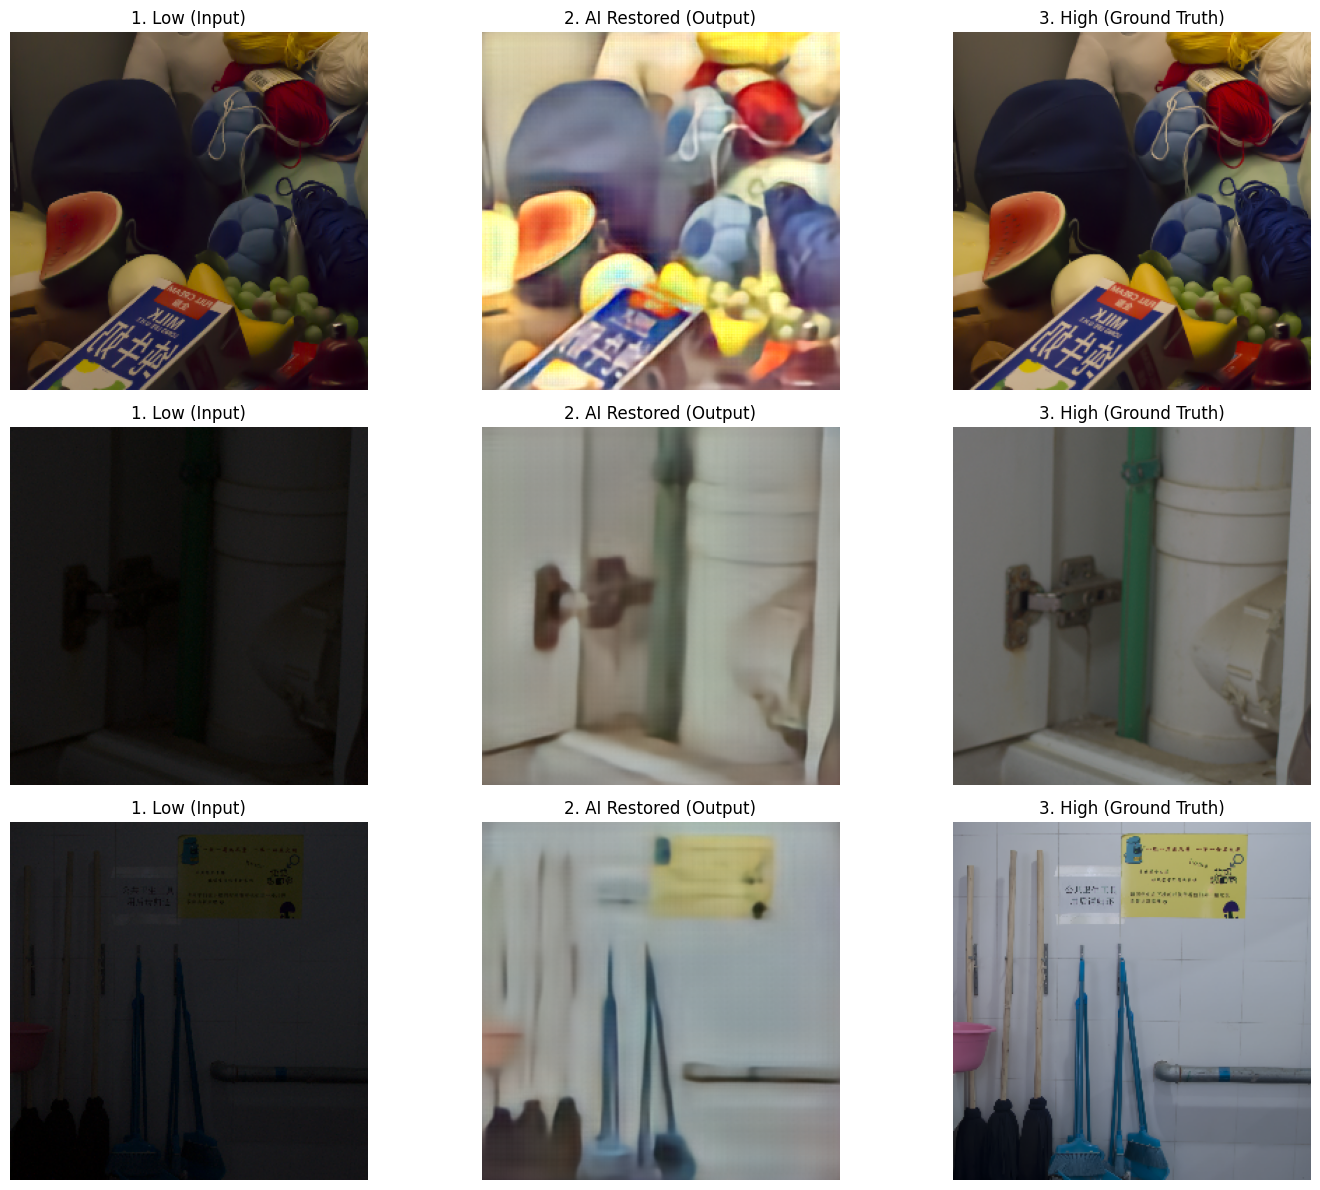

In [7]:
print("🪄 방금 학습한 AI 모델로 복원 테스트를 진행합니다...")

# 모델을 '평가 모드'로 변경 (학습 안 함)
model.eval()

# 데이터 로더에서 딱 한 묶음(4장)만 가져오기
low_img, high_img = next(iter(train_loader))
low_img = low_img.to(device)

# AI 모델에게 어두운 사진을 주고 압축/복원 시켜보기
with torch.no_grad():
    out_net = model(low_img)
    x_hat = out_net['x_hat'].clamp(0, 1) # 안전하게 0~1 사이 값으로 고정

# GPU에 있는 텐서들을 화면에 그리기 위해 CPU로 가져오기
low_img_cpu = low_img.cpu()
high_img_cpu = high_img.cpu()
x_hat_cpu = x_hat.cpu()

# 3장만 뽑아서 비교해봅시다!
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i in range(3):
    # 1. 왼쪽: 원본 어두운 사진 (Input)
    axes[i, 0].imshow(low_img_cpu[i].permute(1, 2, 0))
    axes[i, 0].set_title("1. Low (Input)")
    axes[i, 0].axis('off')

    # 2. 가운데: AI가 압축했다가 복원한 사진 (Output)
    axes[i, 1].imshow(x_hat_cpu[i].permute(1, 2, 0))
    axes[i, 1].set_title("2. AI Restored (Output)")
    axes[i, 1].axis('off')

    # 3. 오른쪽: 우리가 바라는 정답 (Ground Truth)
    axes[i, 2].imshow(high_img_cpu[i].permute(1, 2, 0))
    axes[i, 2].set_title("3. High (Ground Truth)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()